In [1]:
pip install dmba

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 22.4 MB/s eta 0:00:00


In [2]:
pip install mplfinance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.8 MB/s eta 0:00:00


In [3]:
pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29411 sha256=67bf78665d281d88437d33d65438336d4d82c4b39734d5f088178d34ab66806e
  Stored in directory: /root/.cache/pip/wheels/5f/67/4f/8a9f252836e053e532c6587a3230bc72a4deb16b03a829610b
Successfully built ta


In [4]:
#To import required libraries.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from ta import momentum
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.exceptions import ConvergenceWarning

In [5]:
#To import Apple Stock Prices dataset and print the first 2 lines.
df = pd.read_csv("AppleStockPrices.csv", index_col=None)
df.head(2)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1980-12-12,0.100600,0.101037,0.100600,0.100600,469033600,0.0,0.0
1,1980-12-15,0.095789,0.095789,0.095352,0.095352,175884800,0.0,0.0


Initial Data Exploration

In [6]:
#To convert all date columns ('Date', 'announcementDate', and 'releaseDate') to datetime.
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
#To make a copy of the original dataset
df1=df.copy()
#To check that the dataframes concatenated correctly.
df1.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1980-12-12,0.100600,0.101037,0.100600,0.100600,469033600,0.0,0.0
1,1980-12-15,0.095789,0.095789,0.095352,0.095352,175884800,0.0,0.0
2,1980-12-16,0.088790,0.088790,0.088353,0.088353,105728000,0.0,0.0
3,1980-12-17,0.090540,0.090977,0.090540,0.090540,86441600,0.0,0.0
4,1980-12-18,0.093165,0.093602,0.093165,0.093165,73449600,0.0,0.0


In [8]:
#To print descriptive statistics.
df1.describe()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,10274,10274.000000,10274.000000,10274.000000,10274.000000,1.027400e+04,10274.000000,10274.000000
mean,2001-04-19 14:21:58.902082816,11.444107,11.566113,11.320795,11.447856,3.353372e+08,0.000555,0.001655
min,1980-12-12 00:00:00,0.038928,0.038928,0.038490,0.038490,0.000000e+00,0.000000,0.000000
25%,1991-02-08 18:00:00,0.232861,0.237359,0.227112,0.232631,1.272880e+08,0.000000,0.000000
50%,2001-04-10 12:00:00,0.377738,0.384256,0.370018,0.378673,2.233728e+08,0.000000,0.000000
75%,2011-06-27 18:00:00,10.920452,11.023867,10.814811,10.906268,4.176998e+08,0.000000,0.000000
max,2021-09-10 00:00:00,156.979996,157.259995,154.389999,156.690002,7.421641e+09,0.220000,7.000000
std,NaN,24.882509,25.157235,24.603888,24.891118,3.404131e+08,0.009468,0.086560


In [9]:
#To locate missing values.
df1.isna().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

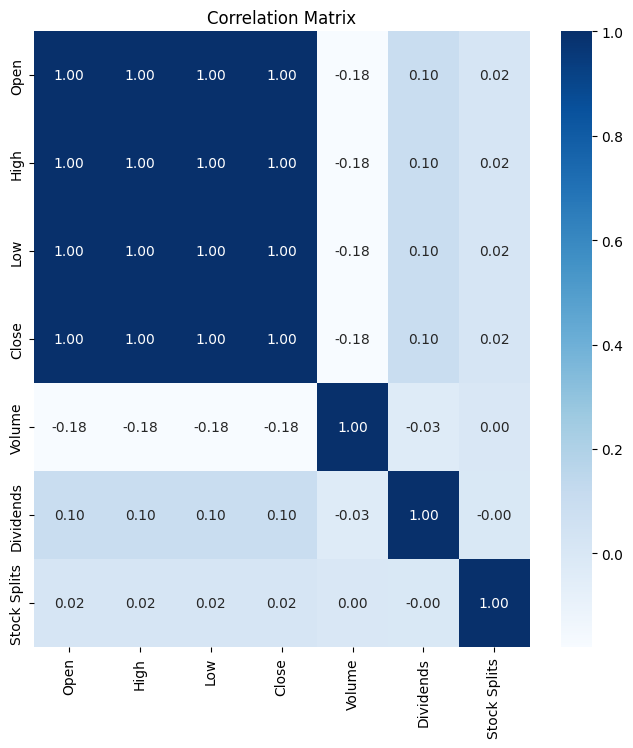

In [10]:
#To calculate the correlation matrix for all of the columns.
corrMat = df1.corr(numeric_only=True)
#To plot and annotate the heatmap, choose the color and round the output.
plt.figure(figsize=(8,8))
sns.heatmap(corrMat, annot=True, fmt=".2f", cmap='Blues')
plt.title('Correlation Matrix')
#To display the visualization
plt.show()

In [11]:
#To drop all columns but 'Close'.
df1 = df1.drop(columns=['Date', 'Volume', 'Open', 'High', 'Low', 'Dividends', 'Stock Splits'])

LSTM Model ('Close' Price Only)

In [12]:
#To make a copy of df1 so it's left unchanged for the classification task.
dfr=df1.copy()
dfr.head(1)

,Close
0,0.1006


In [13]:
#To do some MinMaxScaling since not all columns are of the same measurements.
scaler = MinMaxScaler (feature_range=(0,1))
##To reshape the data as required for LSTM.
dfrLSTM = scaler.fit_transform(dfr['Close'].values.reshape(-1,1))

In [14]:
#To create sequences required for LSTM.
daysInForecast = 10
x = []
y = []
for i in range(daysInForecast, len(dfrLSTM)):
    x.append(dfrLSTM[i-daysInForecast:i, 0])
    y.append(dfrLSTM[i, 0])
x, y = np.array(x), np.array(y)
#To reshape the data as LSTM requires.
x = x.reshape(x.shape[0], x.shape[1], 1)
#To split the data into training and testing sets
xTrain, xTest, yTrain, yTest = train_test_split(x, y, test_size=0.2, shuffle=False)
# To further split the training data into training and validation sets
xTrain, xVal, yTrain, yVal = train_test_split(xTrain, yTrain, test_size=0.2, shuffle=False)

In [15]:
#To set up the LSTM model.
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(xTrain.shape[1], 1)), Dropout(0.2), LSTM(units=50), Dropout(0.2), Dense(units=1)])
#To compile the LSTM model.
model.compile(optimizer='adam', loss='mean_squared_error')
#To define early stopping.
earlyStopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [16]:
#To fit the model using the training and validation data.
history = model.fit(xTrain, yTrain, epochs=100, batch_size=32, verbose=1, validation_data=(xVal, yVal), callbacks=[earlyStopping])

Epoch 1/100
206/206 [==============================] - 18s 38ms/step - loss: 4.3183e-06 - val_loss: 1.1932e-05
Epoch 2/100
206/206 [==============================] - 6s 30ms/step - loss: 3.3288e-07 - val_loss: 8.9511e-06
Epoch 3/100
206/206 [==============================] - 6s 28ms/step - loss: 3.0570e-07 - val_loss: 2.0994e-05
Epoch 4/100
206/206 [==============================] - 7s 34ms/step - loss: 3.6741e-07 - val_loss: 7.7680e-06
Epoch 5/100
206/206 [==============================] - 5s 26ms/step - loss: 2.9692e-07 - val_loss: 2.0918e-05
Epoch 6/100
206/206 [==============================] - 5s 25ms/step - loss: 3.0162e-07 - val_loss: 5.8129e-06
Epoch 7/100
206/206 [==============================] - 3s 15ms/step - loss: 2.4633e-07 - val_loss: 2.3382e-05
Epoch 8/100
206/206 [==============================] - 3s 13ms/step - loss: 2.8948e-07 - val_loss: 5.9183e-06
Epoch 9/100
206/206 [==============================] - 3s 13ms/step - loss: 2.4979e-07 - val_loss: 2.3643e-05
Epoch 10/

In [17]:
#To make predictions on the LSTM test data.
testForecast = model.predict(xTest)
testForecast = scaler.inverse_transform(testForecast.reshape(-1, 1))
testActualPrice = scaler.inverse_transform(yTest.reshape(-1, 1))

#To make predictions on the LSTM validation data.
valForecast = model.predict(xVal)
valForecast = scaler.inverse_transform(valForecast.reshape(-1, 1))
valActualPrice = scaler.inverse_transform(yVal.reshape(-1, 1))

52/52 [==============================] - 0s 4ms/step


RidgeCV Model ('Close' price only)

In [18]:
#To make a copy of df1 so that we are starting with a clean dataset.
dfr1 = df1.copy()
dfr1.head(1)

,Close
0,0.1006


In [19]:
#To define a function to create sequences.
def createSequences(data, daysInForecast):
    x = []
    y = []
    if isinstance(data, pd.DataFrame) or isinstance(data, pd.Series):
        data = data.values
    for i in range(daysInForecast, len(data)):
        x.append(data[i-daysInForecast:i])
        y.append(data[i])
    x, y = np.array(x), np.array(y)
    return x, y

In [20]:
#To define the number of days in the forecast and set it equal to 10.
daysInForecast = 10
#To create sequences using function defined above.
x, y = createSequences(dfr1, daysInForecast)
#To perform train test split to split the data into training and testing sets.
xTrain1, xTest1, yTrain1, yTest1 = train_test_split(x, y, test_size=0.2, shuffle=False)
#To perform train test split to split the data into training and validation sets.
xTrain2, xVal1, yTrain2, yVal1 = train_test_split(xTrain1, yTrain1, test_size=0.2, shuffle=False)

In [21]:
#To reshape
#To flatten into 2D for ridge regression.
flatxTrain = xTrain2.reshape(xTrain2.shape[0], -1)
flatxVal = xVal1.reshape(xVal1.shape[0], -1)
flatxTest = xTest1.reshape(xTest1.shape[0], -1)
#To ravel into 1D arrays for model fitting.
flatyTrain = yTrain2.ravel()
flatyVal = yVal1.ravel()
flatyTest = yTest1.ravel()

In [22]:
#To define the alphas required for Ridge CV.
alphas = np.logspace(-6, 6, 13)

In [23]:
# Initialize and fit the RidgeCV model with cross-validation
ridgeModel = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error')
ridgeModel.fit(flatxTrain, flatyTrain)

RidgeCV(alphas=array([1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01,
       1.e+02, 1.e+03, 1.e+04, 1.e+05, 1.e+06]),
        scoring='neg_mean_squared_error')

In [24]:
#To print the chosen alpha for the RidgeCV model.
chosenAlpha = ridgeModel.alpha_
print("The chosen regularization strength for the RidgeCV model is:", chosenAlpha)

The chosen regularization strength for the RidgeCV model is: 0.01


'Close' Price Only Metrics

In [25]:
#To calculate LSTM metrics on the test data.
#To calculate LSTM mse.
lstmTestMSE = mean_squared_error(testActualPrice, testForecast)
#To calculate LSTM rmse.
lstmTestRMSE = np.sqrt(lstmTestMSE)
#To calculate LSTM r2.
lstmTestR2 = r2_score(testActualPrice, testForecast)
#To calculate LSTM metrics on the validation data.
#To calculate LSTM mse
lstmValMSE = mean_squared_error(valActualPrice, valForecast)
#To calculate LSTM rmse
lstmValRMSE = np.sqrt(lstmValMSE)
#To calculate LSTM r2.
lstmValR2 = r2_score(valActualPrice, valForecast)

In [27]:
#RidgeCV Metrics = test set.
# To make predictions on the test set.
rTestForecast = ridgeModel.predict(flatxTest)
# To calculate MSE for the RidgeCV model's test set.
rTestMSE = mean_squared_error(flatyTest, rTestForecast)
# To calculate RMSE for the RidgeCV model's test set.
rTestRMSE = np.sqrt(rTestMSE)
# To calculate R^2 for the RidgeCV model's test set.
rTestR2 = ridgeModel.score(flatxTest, flatyTest)
#Ridge CV Metrics = validation set.
#To make predictions on the validation set.
rValForecast = ridgeModel.predict(flatxVal)
#To calculate MSE for the RidgeCV model's test set.
rValMSE = mean_squared_error(flatyVal, rValForecast)
#To calculate RMSE for the RidgeCV model's test set.
rValRMSE = np.sqrt(rValMSE)
#To calculate R^2 for the RidgeCV model's test set.
rValR2 = ridgeModel.score(flatxVal, flatyVal)

In [64]:
#To print out test metrics for RidgeCV and LSTM.
print("Using Historic 'Close' Price to Predict Future 'Close' Price")
print("Test Metrics")
print("Model            | Test MSE         | Test RMSE        | Test R^2          ")
print("------------------------------------------------------------------------------------------------------------")
print(f"RidgeCV| {rTestMSE:<16} | {rTestRMSE:<16} | {rTestR2:<16} |")
print(f"LSTM   | {lstmTestMSE:<14} | {lstmTestRMSE:<13} | {lstmTestR2:<14} |")

#To print out validation metrics for RidgeCV and LSTM.
print("Validation Metrics")
print("Model            | Val MSE          | Val RMSE         | Val R^2")
print("--------------------------------------------------------------")
print(f"RidgeCV| {rValMSE:<16} | {rValRMSE:<16} | {rValR2:<16}")
print(f"LSTM   | {lstmValMSE:<14} | {lstmValRMSE:<13} | {lstmValR2:<14}")


Using Historic 'Close' Price to Predict Future 'Close' Price
Test Metrics
Model            | Test MSE         | Test RMSE        | Test R^2          
------------------------------------------------------------------------------------------------------------
RidgeCV| 1.4323606402926126 | 1.1968127005896172 | 0.9988689785971088 |
LSTM   | 26.093144292770713 | 5.108144897393839 | 0.9793963169374557 |
Validation Metrics
Model            | Val MSE          | Val RMSE         | Val R^2
--------------------------------------------------------------
RidgeCV| 0.03714444233818139 | 0.1927289348753357 | 0.998581252272316
LSTM   | 0.14264679437449937 | 0.3776861056148338 | 0.9945515451938227


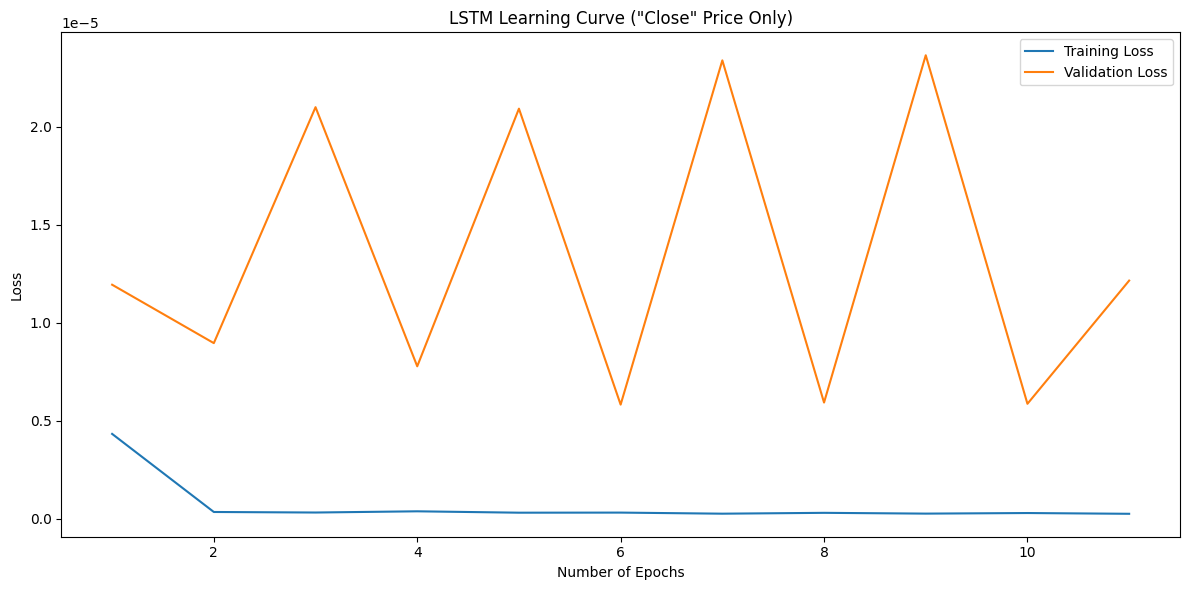

In [29]:
#To create a learning curve for the original LSTM.
#To obtain training and validation losses.
trainLosses = history.history['loss']
valLosses = history.history['val_loss']
#To plot the graph
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(trainLosses) + 1), trainLosses, label='Training Loss')
plt.plot(range(1, len(valLosses) + 1), valLosses, label='Validation Loss')
#To label the axes.
plt.xlabel('Number of Epochs')
plt.ylabel('Loss')
#To title the graph
plt.title('LSTM Learning Curve ("Close" Price Only)')
#To display a legend
plt.legend()
#To display the visualization
plt.tight_layout()
plt.show()

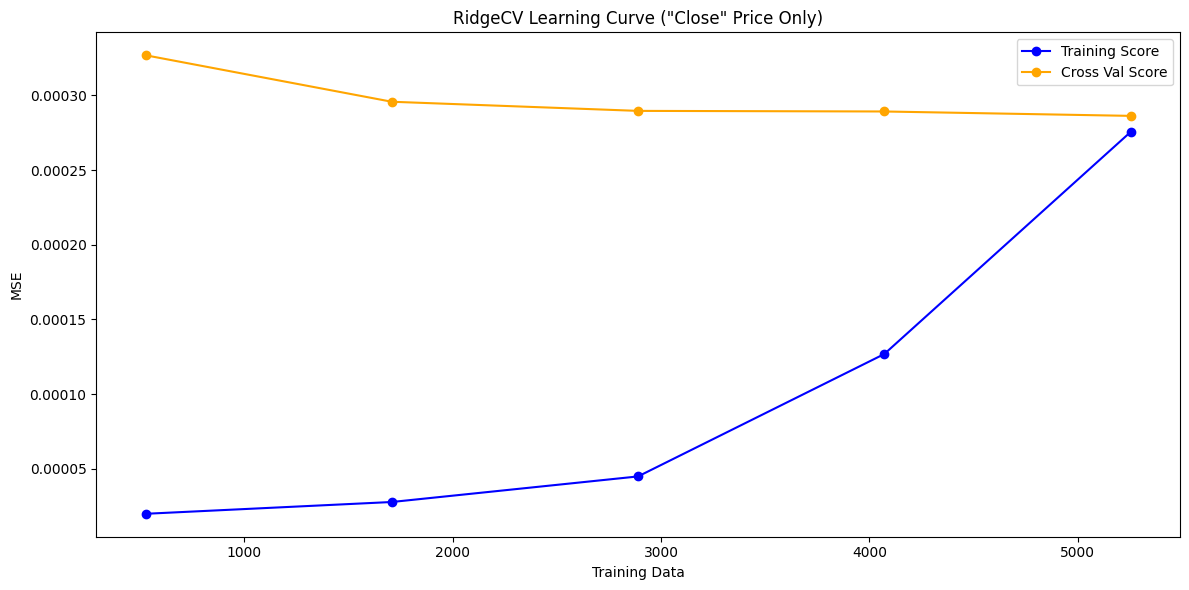

In [30]:
#To plot the learning curve for RidgeCV
trainSizes, trainScores, testScores = learning_curve(
    ridgeModel, flatxTrain, flatyTrain, cv=5, scoring='neg_mean_squared_error')

#To calculate average and standard deviation scores, using both test and training data.
avgTrainScores = -np.mean(trainScores, axis=1)
stdTrainScores = np.std(trainScores, axis=1)
avgTestScores = -np.mean(testScores, axis=1)
stdTestScores = np.std(testScores, axis=1)

#To plot the learning curve using test and training data
plt.figure(figsize=(12, 6))
plt.title('RidgeCV Learning Curve ("Close" Price Only)')
plt.xlabel("Training Data")
plt.ylabel("MSE")
plt.plot(trainSizes, avgTrainScores, 'o-', color="b", label="Training Score")
plt.plot(trainSizes, avgTestScores, 'o-', color="orange", label="Cross Val Score")
plt.legend()
plt.tight_layout()
plt.show()

Additional Exploratory Analysis

In [31]:
#To import Apple Stock Prices dataset and print the first 2 lines.
dfmv = pd.read_csv("AppleStockPrices.csv", index_col=None)
dfmv.head(2)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1980-12-12,0.100600,0.101037,0.100600,0.100600,469033600,0.0,0.0
1,1980-12-15,0.095789,0.095789,0.095352,0.095352,175884800,0.0,0.0


In [32]:
#To convert the date column to datetime.
dfmv['Date'] = pd.to_datetime(dfmv['Date'])

In [36]:
import ta

In [37]:
#To average the daily 'High', 'Low', and 'Close prices.
dfmv['averageDailyPrice']=(dfmv['High'] + dfmv['Low'] + dfmv['Close'])/3
#To get the volume weighted average price.
dfmv['volumeWeightedPrice'] = (dfmv['averageDailyPrice'] * dfmv['Volume']).cumsum() / dfmv['Volume'].cumsum()
#To apply cube root transformation to 'Volume'
dfmv['cubeRootVolume'] = np.cbrt(dfmv['Volume'])
#To calculate RSI based on the close price with a window of 14 days.
dfmv['RSI'] = ta.momentum.rsi(dfmv['Close'], window=14)

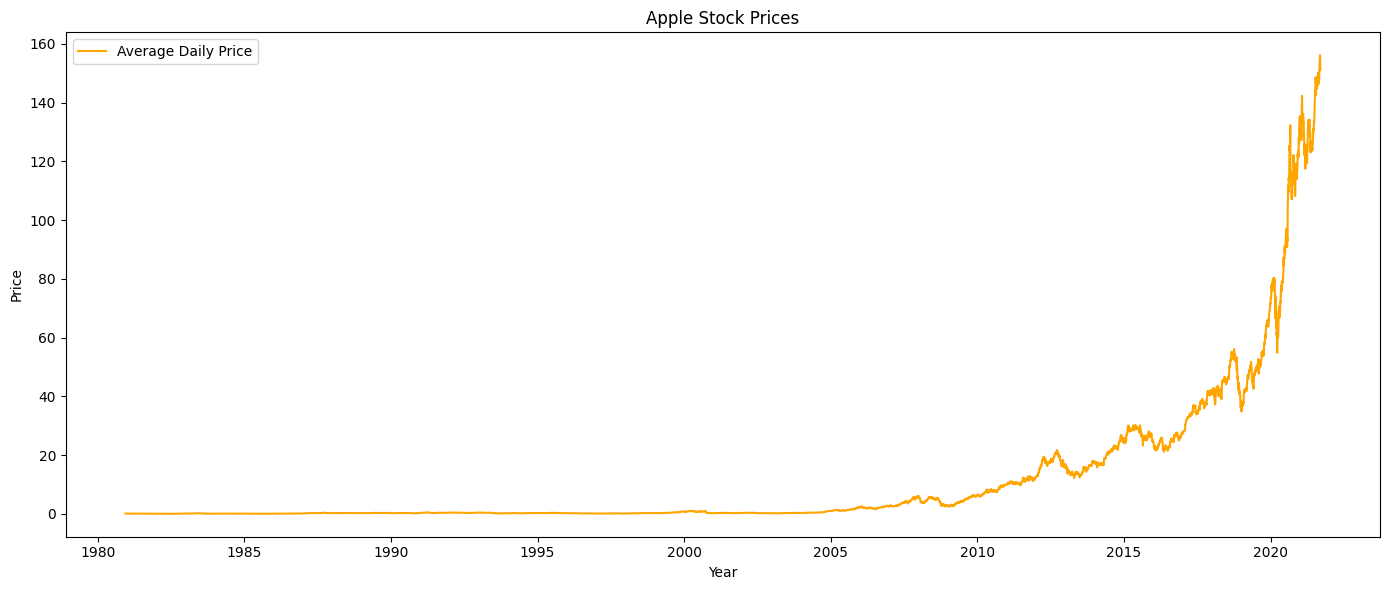

In [38]:
#To create the graph and set the size.
fig, ax = plt.subplots(figsize=(14, 6))
#To plot all of the lines on the graph.
ax.plot(dfmv['Date'], dfmv['averageDailyPrice'], label='Average Daily Price', color='orange')
#To set the labels on the graph
ax.set_xlabel('Year')
ax.set_ylabel('Price')
ax.set_title('Apple Stock Prices')
#To make a map key.
ax.legend()
#To enhance the layout.
plt.tight_layout()
#To show the plot
plt.show()

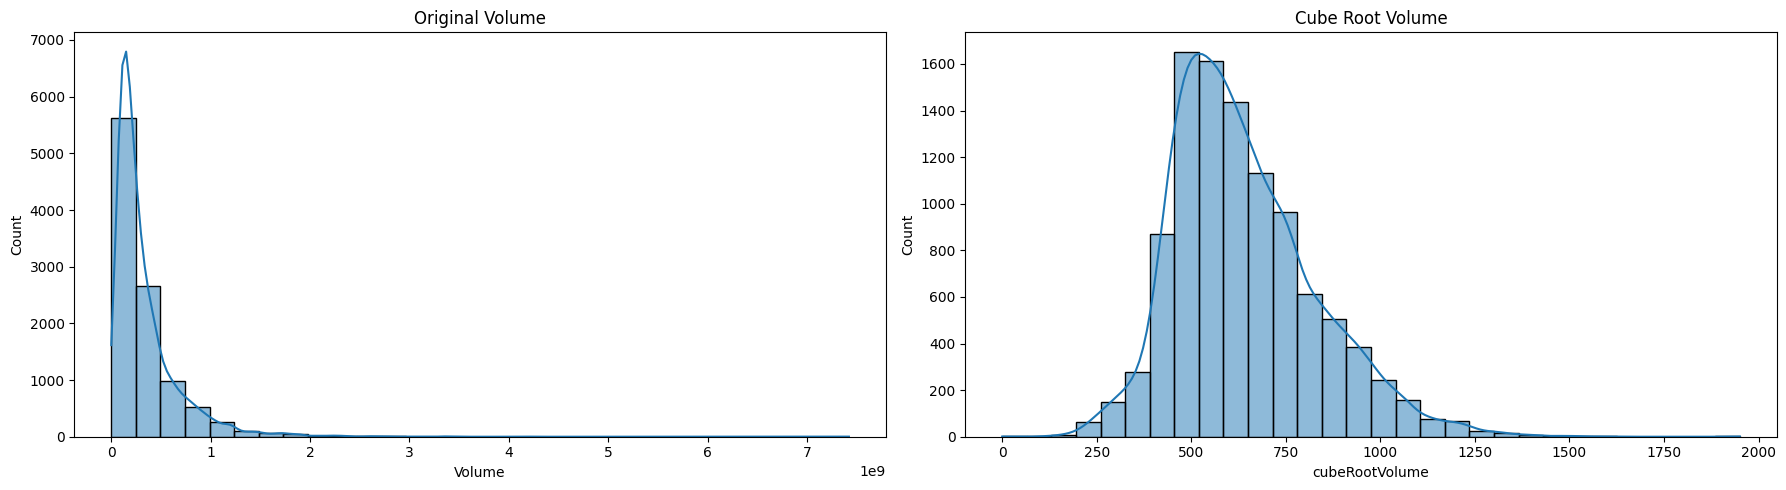

In [39]:
#To visualize the impact of the transformation.
#To plot the visualization for original volume.
fig, ax = plt.subplots(1, 2, figsize=(18, 5))
sns.histplot(dfmv['Volume'], bins=30, kde=True, ax=ax[0])
ax[0].set_title('Original Volume')
#To plot the visualization for cube root volume.
sns.histplot(dfmv['cubeRootVolume'], bins=30, kde=True, ax=ax[1])
ax[1].set_title('Cube Root Volume')
#To display the visualization.
plt.tight_layout()
plt.show()

In [40]:
#To create a dataset of 2000 and beyond.
post2007Df = dfmv[dfmv['Date'].dt.year>=2008].copy()

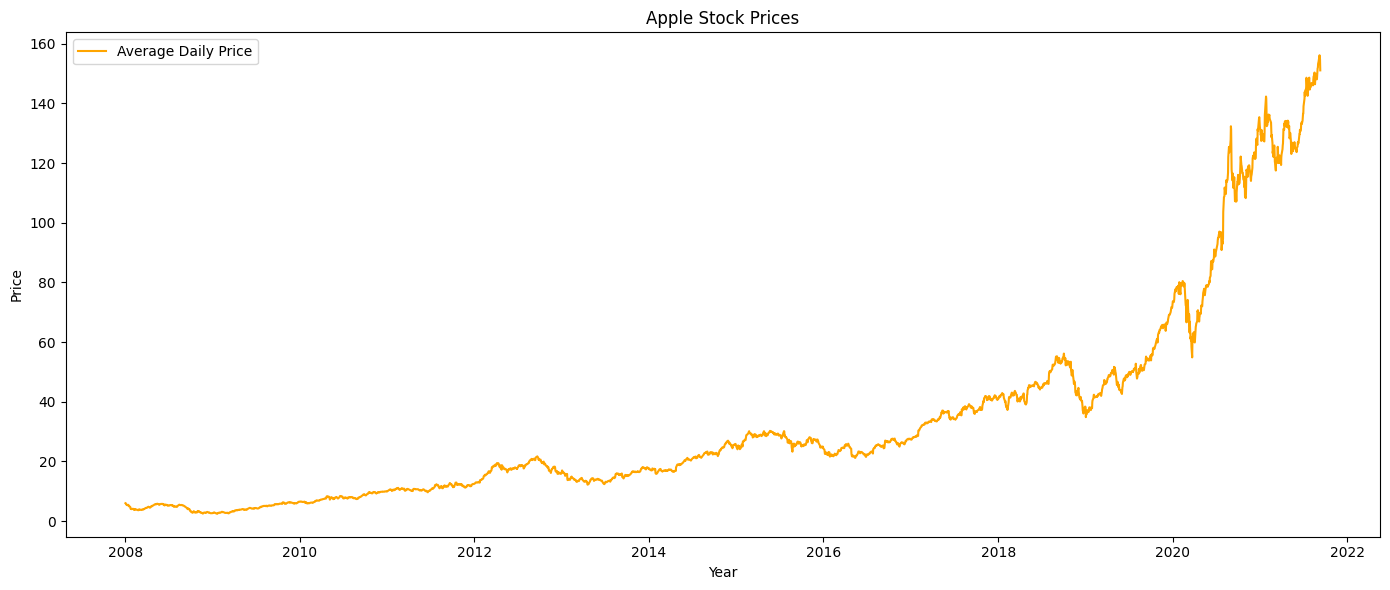

In [41]:
#To create the graph and set the size.
fig, ax = plt.subplots(figsize=(14, 6))
#To plot all of the lines on the graph.
ax.plot(post2007Df['Date'], post2007Df['averageDailyPrice'], label='Average Daily Price', color='orange')
#To set the labels on the graph
ax.set_xlabel('Year')
ax.set_ylabel('Price')
ax.set_title('Apple Stock Prices')
#To make a map key.
ax.legend()
#To enhance the layout.
plt.tight_layout()
#To show the plot
plt.show()

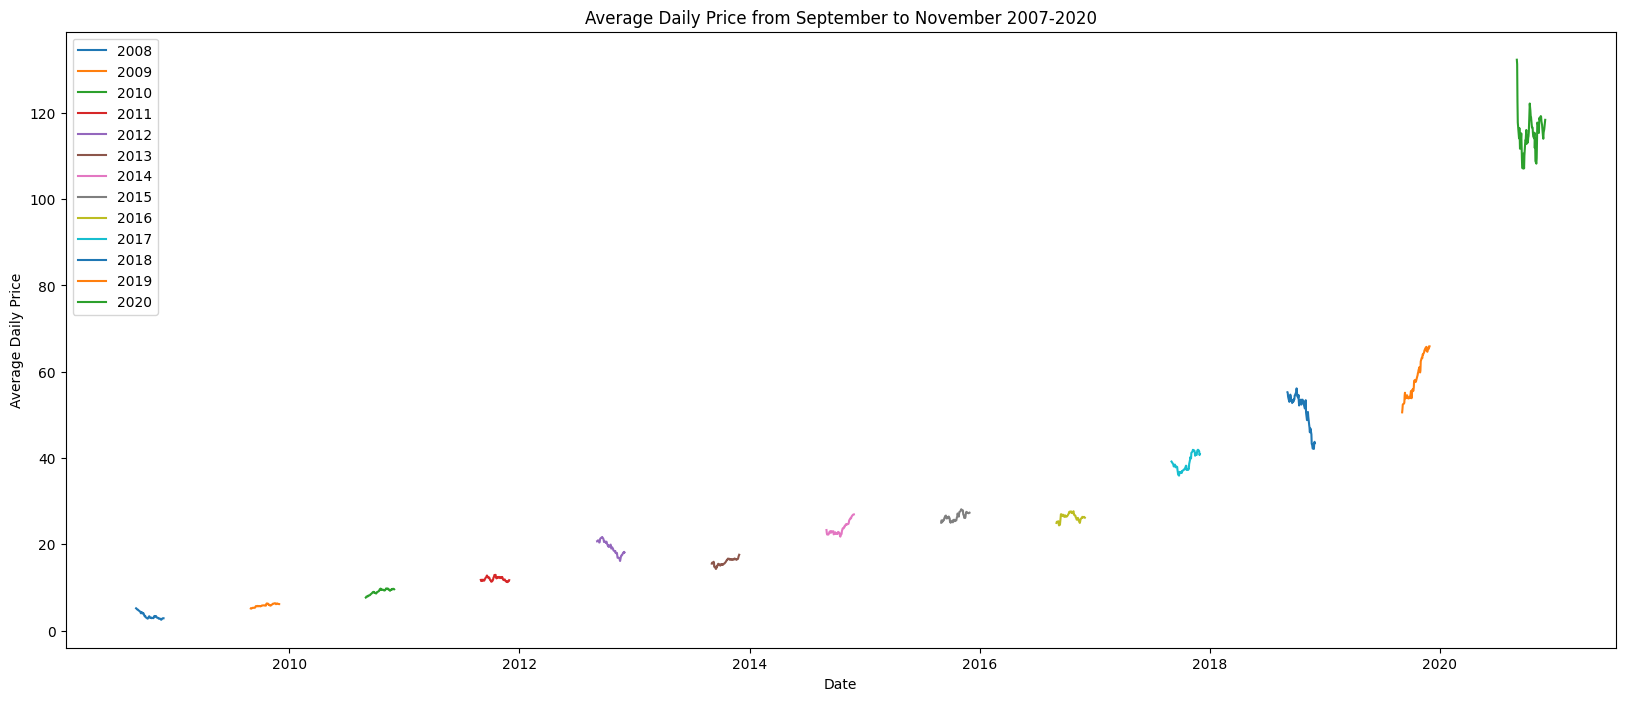

In [42]:
#To filter the dataframe to observe August through October every year from 2007 - 2020.
septToNov = post2007Df[(post2007Df['Date'].dt.year >= 2007) & (post2007Df['Date'].dt.year <= 2020) &
                         ((post2007Df['Date'].dt.month >= 9) & (post2007Df['Date'].dt.month <= 11))]
#To group data by year.
yearlySeptToNov = septToNov.groupby(septToNov['Date'].dt.year)
#To set the size of the visualization
plt.figure(figsize=(20, 8))
#To plot individual lines for each year
for name, group in yearlySeptToNov:
    plt.plot(group['Date'], group['averageDailyPrice'], label=name)
#To add labels to the axes and title the graph.
plt.xlabel('Date')
plt.ylabel('Average Daily Price')
plt.title('Average Daily Price from September to November 2007-2020')
#To add a legend.
plt.legend()
#To display the visualization
plt.show()

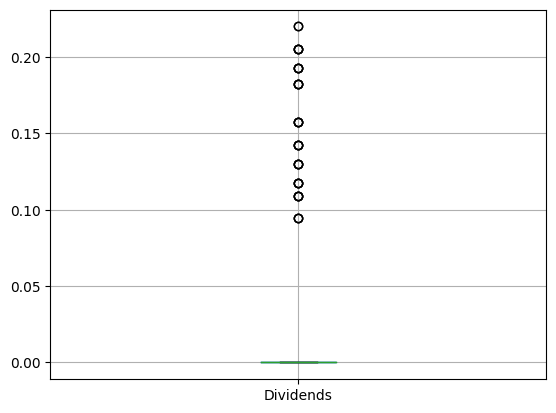

In [43]:
#To create a boxplot to show the spread of dividend data.
post2007Dividends=post2007Df.boxplot(column=['Dividends'])
#Apple's dividends are currently roughly $0.24 per Google

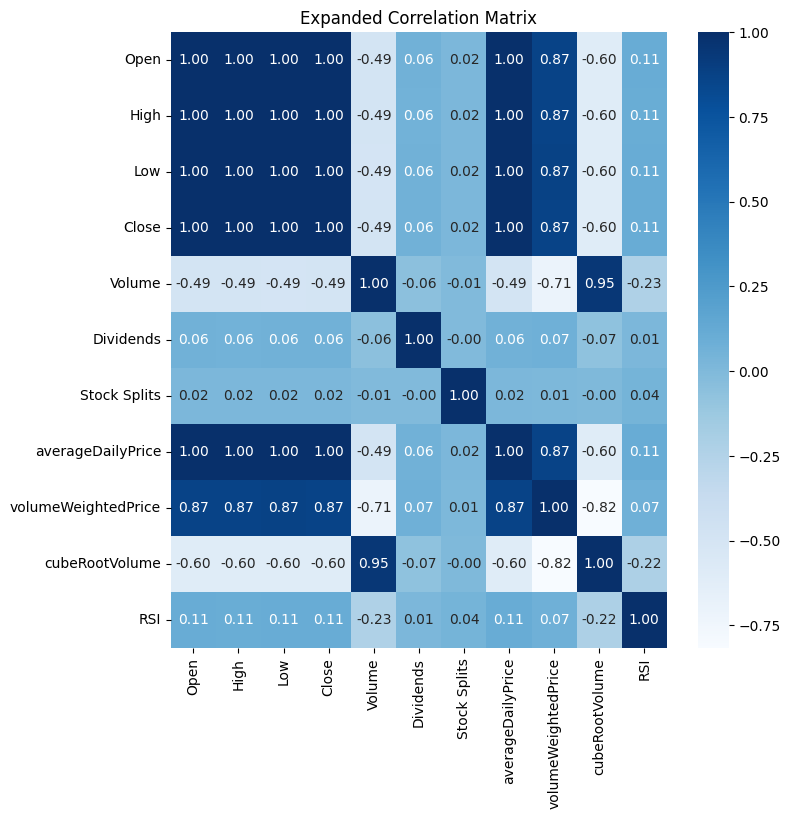

In [44]:
#To take a look at the correlation matrix again but post2000.
corrMat = post2007Df.corr(numeric_only=True)
#To plot and annotate the graph, and round to the second decimal place.
plt.figure(figsize=(8,8))
sns.heatmap(corrMat, annot=True, fmt=".2f", cmap='Blues')
plt.title('Expanded Correlation Matrix')
#To display the visualization.
plt.show()

In [45]:
# Make a copy of df1 so it's left unchanged for the classification task.
post2007LSTM = post2007Df.copy()

LSTM with Multiple Variables

In [46]:
# To select features to be scaled.
featuresScaled = ['averageDailyPrice', 'volumeWeightedPrice', 'cubeRootVolume', 'RSI', 'Close']
# To initialize the MinMaxScaler.
scaler = MinMaxScaler(feature_range=(0, 1))
# To scale the features defined in 'featuresScaled'
post2007LSTM[featuresScaled] = scaler.fit_transform(post2007LSTM[featuresScaled])

In [47]:
# To define the number of days to use to forecast.
daysInForecast1 = 10
#To define the features to be used to forecast.
features = ['volumeWeightedPrice', 'cubeRootVolume', 'averageDailyPrice']
#To define the target variable.
targetColumn = 'Close'
x = []
y = []
#To define a function to predict the next close value.
for i in range(daysInForecast1, len(post2007LSTM)):
    x.append(post2007LSTM[features].iloc[i-daysInForecast1:i].values)
    y.append(post2007LSTM[targetColumn].iloc[i])
x, y = np.array(x), np.array(y)
# To reshape the data as required for LSTM.
x = x.reshape(x.shape[0], x.shape[1], len(features))
#To split the data into training and testing sets, and then into training and validation sets.
xTrain3, xTest3, yTrain3, yTest3 = train_test_split(x, y, test_size=0.2, shuffle=False)
xTrain4, xVal3, yTrain4, yVal3 = train_test_split(xTrain3, yTrain3, test_size=0.2, shuffle=False)

In [48]:
#To set up early stopping to aid in overfitting prevention.
earlyStopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [49]:
#To set up the LSTM model.
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(10,3)), Dropout(0.2), LSTM(units=50), Dropout(0.2), Dense(units=1)])
#To compile the LSTM model.
model.compile(optimizer='adam', loss='mean_squared_error')

In [50]:
#To fit the model using the training and validation data.
history = model.fit(xTrain4, yTrain4, epochs=100, batch_size=32, verbose=1, validation_data=(xVal3, yVal3), callbacks=[earlyStopping])

Epoch 1/100
69/69 [==============================] - 6s 26ms/step - loss: 0.0010 - val_loss: 0.0051
Epoch 2/100
69/69 [==============================] - 1s 13ms/step - loss: 3.0554e-04 - val_loss: 0.0016
Epoch 3/100
69/69 [==============================] - 1s 13ms/step - loss: 1.7687e-04 - val_loss: 6.0340e-04
Epoch 4/100
69/69 [==============================] - 1s 14ms/step - loss: 1.2354e-04 - val_loss: 9.6439e-05
Epoch 5/100
69/69 [==============================] - 1s 13ms/step - loss: 9.4279e-05 - val_loss: 1.0669e-04
Epoch 6/100
69/69 [==============================] - 1s 13ms/step - loss: 8.9305e-05 - val_loss: 1.1876e-04
Epoch 7/100
69/69 [==============================] - 1s 19ms/step - loss: 8.3132e-05 - val_loss: 8.9778e-05
Epoch 8/100
69/69 [==============================] - 1s 21ms/step - loss: 7.4834e-05 - val_loss: 7.9518e-05
Epoch 9/100
69/69 [==============================] - 1s 21ms/step - loss: 7.6067e-05 - val_loss: 1.1562e-04
Epoch 10/100
69/69 [====================

In [51]:
#Test Data
#To make predictions on the LSTM test data.
testForecast1 = model.predict(xTest3)
#To reshape
testForecast1 = testForecast1.reshape(-1, 1)
#To employ inverse_transform to get the variables back to their original scale.
testForecast1 = scaler.inverse_transform(np.concatenate([np.zeros((testForecast1.shape[0], len(featuresScaled) - 1)), testForecast1], axis=1))[:, -1]
#To reshape.
testActualPrice1 = scaler.inverse_transform(np.concatenate([np.zeros((yTest3.shape[0], len(featuresScaled) - 1)), yTest3.reshape(-1, 1)], axis=1))[:, -1]
#Validation Data
#To make predictions on the LSTM validation data.
valForecast1 = model.predict(xVal3)
#To reshape
valForecast1 = valForecast1.reshape(-1, 1)
#To employ inverse_transform to get the variables back to their original scale.
valForecast1 = scaler.inverse_transform(np.concatenate([np.zeros((valForecast1.shape[0], len(featuresScaled) - 1)), valForecast1], axis=1))[:, -1]
#To reshape.
valActualPrice1 = scaler.inverse_transform(np.concatenate([np.zeros((yVal3.shape[0], len(featuresScaled) - 1)), yVal3.reshape(-1, 1)], axis=1))[:, -1]

18/18 [==============================] - 0s 4ms/step


In [52]:
#To make a copy of post2007Df for use with the LassoCV model.
post2007Df1 = post2007Df.copy()

Lasso CV with Multiple Variables.

In [53]:
#To define a function to create sequences.
def createSequences1(dataFrame, daysInForecast, features, targetColumn):
#    if targetColumn not in dataFrame.columns:
#        raise ValueError(f"Target column '{targetColumn}' not found in DataFrame.")
    x = []
    y = []
    for i in range(daysInForecast, len(dataFrame)):
        x.append(dataFrame[features].iloc[i-daysInForecast:i].values)
        y.append(dataFrame[targetColumn].iloc[i])
    x, y = np.array(x), np.array(y)
    return x, y
#To define the predictor features and target variable.
features = ['cubeRootVolume', 'volumeWeightedPrice', 'averageDailyPrice']
targetColumn = 'Close'
#To actually create the sequences.
x, y = createSequences1(post2007Df1, 10, features, targetColumn)
#To train test split, and then further split into training and validation data.
xTrain5, xTest5, yTrain5, yTest5 = train_test_split(x, y, test_size=0.2, shuffle=False)
xTrain6, xVal5, yTrain6, yVal5 = train_test_split(xTrain5, yTrain5, test_size=0.2, shuffle=False)

In [54]:
#To reshape xTrain, xTest, and xVal.
flatxTrain1 = xTrain6.reshape(xTrain6.shape[0], -1)
flatxVal1 = xVal5.reshape(xVal5.shape[0], -1)
flatxTest1 = xTest5.reshape(xTest5.shape[0], -1)
#To reshape yTrain, yTest, and yVal.
flatyTrain1 = yTrain6.ravel()
flatyVal1 = yVal5.ravel()
flatyTest1 = yTest5.ravel()

In [55]:
#To normalize the features (x)
scalerX = StandardScaler()
flatxTrain1 = scalerX.fit_transform(flatxTrain1)
flatxVal1 = scalerX.transform(flatxVal1)
flatxTest1 = scalerX.transform(flatxTest1)

In [56]:
#To normalize the targetColumn (y)
scalerY = StandardScaler()
flatyTrain1 = scalerY.fit_transform(flatyTrain1.reshape(-1, 1)).ravel()
flatyVal1 = scalerY.transform(flatyVal1.reshape(-1, 1)).ravel()
flatyTest1 = scalerY.transform(flatyTest1.reshape(-1, 1)).ravel()

In [57]:
#To choose alphas for the Lasso model.
alphas = np.logspace(-6, 1, 10)

In [58]:
#To initialize the Lasso model.
lassoModel = LassoCV(alphas=alphas, max_iter=100000, random_state=42)
#To fit the Lasso model.
lassoModel.fit(flatxTrain1, flatyTrain1)

LassoCV(alphas=array([1.00000000e-06, 5.99484250e-06, 3.59381366e-05, 2.15443469e-04,
       1.29154967e-03, 7.74263683e-03, 4.64158883e-02, 2.78255940e-01,
       1.66810054e+00, 1.00000000e+01]),
        max_iter=100000, random_state=42)

In [59]:
#To print the chosen alpha for the Lasso model with more variables.
chosenAlpha1 = lassoModel.alpha_
print("The chosen regularization strength for LassoCV is:", chosenAlpha1)

The chosen regularization strength for LassoCV is: 5.994842503189409e-06


Multiple Variable Metrics

In [60]:
#To calculate LSTM Metrics
#To calculate LSTM test metrics.
#To calculate MSE, RMSE, and R2
lstmTestMSE1 = mean_squared_error(testActualPrice1, testForecast1)
lstmTestRMSE1 = np.sqrt(lstmTestMSE1)
lstmTestR21 = r2_score(testActualPrice1, testForecast1)
#To calculate LSTM validation metrics.
#To calculate MSE, RMSE, and R2.
lstmValMSE1 = mean_squared_error(valActualPrice1, valForecast1)
lstmValRMSE1 = np.sqrt(lstmValMSE1)
lstmValR21 = r2_score(valActualPrice1, valForecast1)

In [65]:
#Predictions and Metrics
#Linear Regression (LassoCV)
#To make predictions on the test data using the Lasso model.
lrTestForecast1 = lassoModel.predict(flatxTest1)
lrTestForecast1_original = scalerY.inverse_transform(lrTestForecast1.reshape(-1, 1)).ravel()
flatyTest1OG = scalerY.inverse_transform(flatyTest1.reshape(-1, 1)).ravel()
#To calculate MSE for the Lasso model.
lrTestMSE1 = mean_squared_error(flatyTest1OG, lrTestForecast1_original)
#To calculate RMSE for the Lasso model.
lrTestRMSE1 = np.sqrt(lrTestMSE1)
#To calculate R^2 for the Lasso model.
lrTestR21 = lassoModel.score(flatxTest1, flatyTest1)
# Validation metrics
#To make predictions on validation data using Lasso Model.
lrValForecast1 = lassoModel.predict(flatxVal1)
lrValForecast1OG = scalerY.inverse_transform(lrValForecast1.reshape(-1, 1)).ravel()
flatyVal1OG = scalerY.inverse_transform(flatyVal1.reshape(-1, 1)).ravel()
#To calculate MSE for the Lasso model.
lrValMSE1 = mean_squared_error(flatyVal1OG, lrValForecast1OG)
#To calculate RMSE for the Lasso model.
lrValRMSE1 = np.sqrt(lrValMSE1)
#To calculate R^2 for the Lasso model.
lrValR21 = lassoModel.score(flatxVal1, flatyVal1)
#To print all test metrics.
print("Using Multiple Variables to Predict Future 'Close' Price")
print("Test Metrics")
print("Model            | Test MSE         | Test RMSE        | Test R^2          ")
print("------------------------------------------------------------------------------------------------------------")
print(f"LassoCV| {lrTestMSE1:<16} | {lrTestRMSE1:<16} | {lrTestR21:<16} |")
print(f"LSTM   | {lstmTestMSE1:<14} | {lstmTestRMSE1:<13} | {lstmTestR21:<14} |")
#To print all validation metrics.
print("Validation Metrics")
print("Model            | Val MSE          | Val RMSE         | Val R^2")
print("--------------------------------------------------------------")
print(f"LassoCV| {lrValMSE1:<16} | {lrValRMSE1:<16} | {lrValR21:<16}")
print(f"LSTM   | {lstmValMSE1:<14} | {lstmValRMSE1:<13} | {lstmValR21:<14}")

Using Multiple Variables to Predict Future 'Close' Price
Test Metrics
Model            | Test MSE         | Test RMSE        | Test R^2          
------------------------------------------------------------------------------------------------------------
LassoCV| 4.090479744971962 | 2.0224934474484613 | 0.996881374535632 |
LSTM   | 45.89801904676123 | 6.774807675997986 | 0.9650068598581318 |
Validation Metrics
Model            | Val MSE          | Val RMSE         | Val R^2
--------------------------------------------------------------
LassoCV| 0.36366114212683737 | 0.6030432340444899 | 0.9937493890713675
LSTM   | 1.8930109450171593 | 1.3758673428122201 | 0.9674629111272537


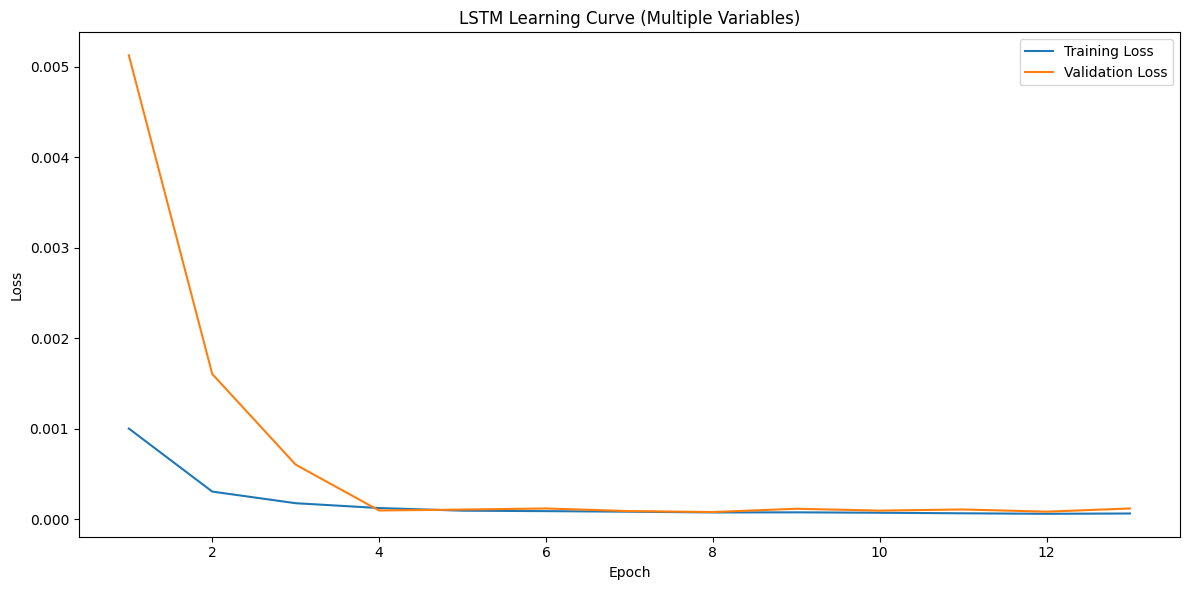

In [62]:
#To create a learning curve for LSTM with multiple variables.
#To obtain training and validation losses.
trainLosses = history.history['loss']
valLosses = history.history['val_loss']
#To plot the graph
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(trainLosses) + 1), trainLosses, label='Training Loss')
plt.plot(range(1, len(valLosses) + 1), valLosses, label='Validation Loss')
#To label the axes.
plt.xlabel('Epoch')
plt.ylabel('Loss')
#To title the visualization
plt.title('LSTM Learning Curve (Multiple Variables)')
#To display a legend
plt.legend()
#To display the visualization
plt.tight_layout()
plt.show()

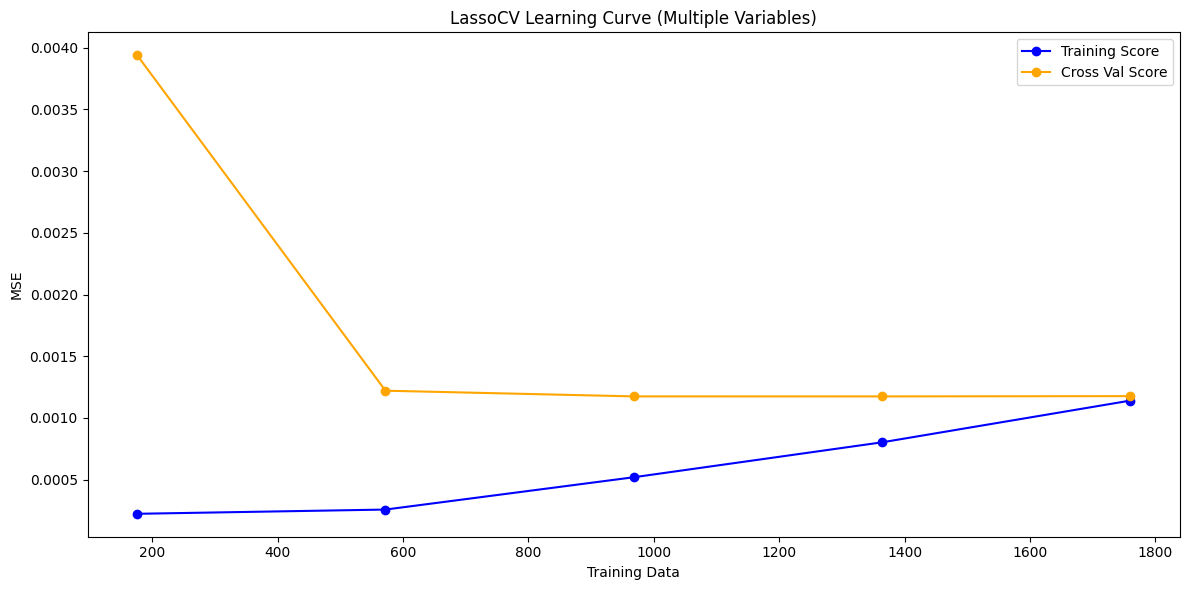

In [63]:
#To suppress the convergence warning as it is only present during the visualization
#and not during model fitting.
warnings.filterwarnings(action='ignore', category=ConvergenceWarning)
#To plot the learning curve for LassoCV
trainSizes, trainScores, testScores = learning_curve(
    lassoModel, flatxTrain1, flatyTrain1, cv=5, scoring='neg_mean_squared_error')
#To calculate average and standard deviation scores, using both test and training data.
avgTrainScores = -np.mean(trainScores, axis=1)
stdTrainScores = np.std(trainScores, axis=1)
avgTestScores = -np.mean(testScores, axis=1)
stdTestScores = np.std(testScores, axis=1)
#To plot the learning curve using test and training data
plt.figure(figsize=(12, 6))
#To title the visualization
plt.title('LassoCV Learning Curve (Multiple Variables)')
#To label the axes
plt.xlabel("Training Data")
plt.ylabel("MSE")
plt.plot(trainSizes, avgTrainScores, 'o-', color="b", label="Training Score")
plt.plot(trainSizes, avgTestScores, 'o-', color="orange", label="Cross Val Score")
plt.legend()
plt.tight_layout()
plt.show()